# Health Data Quality Stress Lab

**Two experiments in one self-contained notebook:** first, an auditable cleaning pipeline for synthetic wearable observations; then a controlled data-quality experiment on the real Wisconsin Diagnostic Breast Cancer dataset.

The second experiment asks: **how do parsing errors, missing measurements and duplicate conflicts affect a model, and does a more complex imputer help?** It adds row reconciliation, quarantine, reproducible corruption, training-only model selection, bootstrap intervals and stress testing.

Run top to bottom in Jupyter or Colab. No repository modules or separate data files are required. All simulated corruptions are identified as simulations; this is a research demonstration, not a medical service.

In [1]:
# Optional: uncomment in Jupyter/Colab if needed.
# %pip install "numpy>=1.26,<3" "pandas>=2.2,<3" "scikit-learn>=1.5,<2"

## 1. Imports and schema

Each ID represents one independent observation. Repeated observations from the same patient would require a patient-level split. The numeric bounds below are illustrative quality rules, not clinical standards.

In [2]:
import json
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC = {'age': (18, 100), 'sleep_hours': (0, 24), 'steps': (0, 100000), 'resting_hr': (30, 220)}
REQUIRED = ['record_id', *NUMERIC, 'activity']
print('Expected columns:', REQUIRED)

Expected columns: ['record_id', 'age', 'sleep_hours', 'steps', 'resting_hr', 'activity']


## 2. Generate deliberately messy observations

The sample includes exact duplicates, numeric text, missing values, impossible measurements and inconsistent category formatting. Units: age in years, sleep in hours, steps per day and resting heart rate in beats per minute.

In [3]:
def sample_data(n=200, seed=42):
    """Artificial observations only; injected errors are intentional."""
    rng = np.random.default_rng(seed)
    frame = pd.DataFrame({'record_id': [f'S{i:04d}' for i in range(n)],
        'age': rng.integers(18, 85, n).astype(str),
        'sleep_hours': rng.uniform(4, 10, n).round(1).astype(str),
        'steps': rng.integers(500, 18000, n).astype(str),
        'resting_hr': rng.integers(45, 100, n).astype(str),
        'activity': rng.choice(['low', 'moderate', 'high', ' HIGH ', 'unknown'], n)})
    frame.loc[0, 'age'] = 'two'
    frame.loc[1, 'sleep_hours'] = '29'
    frame.loc[2, 'steps'] = '-30'
    frame.loc[3, 'resting_hr'] = ''
    frame.loc[4, 'age'] = '999'
    return pd.concat([frame, frame.iloc[:5]], ignore_index=True)

raw = sample_data()
print("Raw shape:", raw.shape)
print(raw.head(8).to_string(index=False))

Raw shape: (205, 6)
record_id age sleep_hours steps resting_hr activity
    S0000 two         9.5 11284         45  unknown
    S0001  69          29 14132         61    HIGH 
    S0002  61         5.6   -30         73     high
    S0003  47         9.8  2854             unknown
    S0004 999         8.7 14955         85      low
    S0005  75         8.3  9881         87  unknown
    S0006  23         6.7  6153         74  unknown
    S0007  64         5.6  9498         51     high


## 3. Inspect before cleaning

Numeric columns arrive as text. Empty strings and semantic errors need more than a simple `isna()` check.

In [4]:
print(raw.dtypes.to_string())
print("Exact duplicate rows:", int(raw.duplicated().sum()))
print("Raw activity values:")
print(raw.activity.value_counts(dropna=False).to_string())

record_id      object
age            object
sleep_hours    object
steps          object
resting_hr     object
activity       object
Exact duplicate rows: 5
Raw activity values:
activity
unknown     44
high        44
 HIGH       41
low         39
moderate    37


## 4. Clean with explicit rules

Remove exact duplicates; reject conflicting IDs. Parse numeric strings, recording missing, unparseable and out-of-range values separately. Invalid numbers become missing rather than fabricated values. Normalise activity labels and mark unsupported labels as missing. All transformations here use fixed rules, not statistics learned from the dataset.

In [5]:
def clean_data(raw):
    missing = set(REQUIRED) - set(raw.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')
    frame = raw[REQUIRED].copy()
    frame['record_id'] = frame['record_id'].astype('string').str.strip()
    if frame['record_id'].isna().any() or frame['record_id'].eq('').any():
        raise ValueError('Every observation needs a nonempty record_id')
    original_count = len(frame)
    frame = frame.drop_duplicates()
    duplicate_count = original_count - len(frame)
    if frame['record_id'].duplicated().any():
        raise ValueError('Conflicting observations share a record_id; resolve upstream')
    report = {'input_rows': original_count, 'exact_duplicates_removed': duplicate_count,
              'output_rows': len(frame), 'numeric_issues': {}}
    for column, (lower, upper) in NUMERIC.items():
        text = frame[column].astype('string').str.strip()
        absent = text.isna() | text.isin(['', 'NA', 'N/A', 'unknown'])
        values = pd.to_numeric(text.mask(absent), errors='coerce')
        invalid = values.notna() & ~values.between(lower, upper)
        report['numeric_issues'][column] = {
            'missing': int(absent.sum()),
            'unparseable': int((values.isna() & ~absent).sum()),
            'out_of_range': int(invalid.sum())}
        frame[column] = values.mask(invalid).astype(float)
    activity = frame['activity'].astype('string').str.strip().str.lower()
    valid = activity.isin(['low', 'moderate', 'high'])
    report['unknown_activity_values'] = int((~valid).sum())
    frame['activity'] = activity.where(valid).astype(object).where(valid, np.nan)
    report['missing_after_cleaning'] = {c: int(frame[c].isna().sum()) for c in REQUIRED}
    return frame.reset_index(drop=True), report

cleaned, report = clean_data(raw)
print(cleaned.head(8).to_string(index=False))
print(json.dumps(report, indent=2))

record_id  age  sleep_hours   steps  resting_hr activity
    S0000  NaN          9.5 11284.0        45.0      NaN
    S0001 69.0          NaN 14132.0        61.0     high
    S0002 61.0          5.6     NaN        73.0     high
    S0003 47.0          9.8  2854.0         NaN      NaN
    S0004  NaN          8.7 14955.0        85.0      low
    S0005 75.0          8.3  9881.0        87.0      NaN
    S0006 23.0          6.7  6153.0        74.0      NaN
    S0007 64.0          5.6  9498.0        51.0     high
{
  "input_rows": 205,
  "exact_duplicates_removed": 5,
  "output_rows": 200,
  "numeric_issues": {
    "age": {
      "missing": 0,
      "unparseable": 1,
      "out_of_range": 1
    },
    "sleep_hours": {
      "missing": 0,
      "unparseable": 0,
      "out_of_range": 1
    },
    "steps": {
      "missing": 0,
      "unparseable": 0,
      "out_of_range": 1
    },
    "resting_hr": {
      "missing": 1,
      "unparseable": 0,
      "out_of_range": 0
    }
  },
  "unknown_act

## 5. Compare data quality

The table shows missing values after parsing and validation. This is an honest view of uncertainty: invalid measurements have been exposed, not magically recovered.

In [6]:
quality = pd.DataFrame(report['numeric_issues']).T
quality['missing_after_cleaning'] = cleaned[list(NUMERIC)].isna().sum()
print(quality.to_string())
print('\nClean numeric summaries:')
print(cleaned[list(NUMERIC)].describe().round(2).to_string())

             missing  unparseable  out_of_range  missing_after_cleaning
age                0            1             1                       2
sleep_hours        0            0             1                       1
steps              0            0             1                       1
resting_hr         1            0             0                       1

Clean numeric summaries:
          age  sleep_hours     steps  resting_hr
count  198.00       199.00    199.00      199.00
mean    51.77         6.91   9690.32       71.19
std     18.37         1.80   4892.67       16.16
min     18.00         4.10    585.00       45.00
25%     37.00         5.20   5681.50       57.00
50%     51.00         6.90   9870.00       73.00
75%     68.00         8.60  13856.00       84.00
max     84.00        10.00  17941.00       99.00


## 6. Split before learning preprocessing statistics

Median imputation, scaling and encoding must fit only on training rows. ID is retained for traceability but excluded from the feature matrix. There is no target column or predictive model in this starter experiment.

In [7]:
train, test = train_test_split(cleaned, test_size=0.2, random_state=42)
assert set(train.record_id).isdisjoint(test.record_id)
print(f'Training rows: {len(train)}; test rows: {len(test)}')

Training rows: 160; test rows: 40


## 7. Impute, scale and encode

Numeric missing values use training medians; columns with training missingness receive indicators. StandardScaler learns training means and standard deviations. Activity missingness becomes an explicit unknown category. Unseen test categories are accepted and encoded as zeros in the category block.

In [8]:
def make_preprocessor():
    return ColumnTransformer([
        ('numeric', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True,
                                                      keep_empty_features=True)),
                              ('scale', StandardScaler())]), list(NUMERIC)),
        ('category', Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='unknown')),
                               ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
         ['activity'])], remainder='drop')

processor = make_preprocessor()
train_values = processor.fit_transform(train)
test_values = processor.transform(test)
feature_names = processor.get_feature_names_out()
train_features = pd.DataFrame(train_values, columns=feature_names, index=train.record_id)
test_features = pd.DataFrame(test_values, columns=feature_names, index=test.record_id)
print('Training feature shape:', train_features.shape)
print('Test feature shape:', test_features.shape)
print(train_features.head().round(3).to_string())

Training feature shape: (160, 12)
Test feature shape: (40, 12)
           numeric__age  numeric__sleep_hours  numeric__steps  numeric__resting_hr  numeric__missingindicator_age  numeric__missingindicator_sleep_hours  numeric__missingindicator_steps  numeric__missingindicator_resting_hr  category__activity_high  category__activity_low  category__activity_moderate  category__activity_unknown
record_id                                                                                                                                                                                                                                                                                                                                
S0079             0.555                 0.923           1.502                0.561                         -0.113                                 -0.079                           -0.079                                -0.079                      0.0                     0.0     

## 8. Validate the results

Check duplicate removal, known corruptions, idempotency, ID conflicts, finite output and training-only statistics. Challenge the fitted processor with an unseen category and confirm that transforming new data does not change learned statistics.

In [9]:
assert report['exact_duplicates_removed'] == 5
assert len(cleaned) == 200
assert pd.isna(cleaned.loc[0, 'age'])
assert pd.isna(cleaned.loc[1, 'sleep_hours'])
assert pd.isna(cleaned.loc[2, 'steps'])
assert pd.isna(cleaned.loc[3, 'resting_hr'])
assert pd.isna(cleaned.loc[4, 'age'])
assert clean_data(cleaned)[0].equals(cleaned)
assert np.isfinite(train_values).all() and np.isfinite(test_values).all()
imputer = processor.named_transformers_['numeric'].named_steps['impute']
np.testing.assert_allclose(imputer.statistics_, train[list(NUMERIC)].median().to_numpy())
stats_before = imputer.statistics_.copy()
challenge = test.head().copy()
challenge['activity'] = 'unseen'
challenge['age'] = 100
assert np.isfinite(processor.transform(challenge)).all()
np.testing.assert_array_equal(imputer.statistics_, stats_before)
conflicting = raw.iloc[:10].copy()
conflicting.loc[1, 'record_id'] = conflicting.loc[0, 'record_id']
try:
    clean_data(conflicting)
except ValueError as error:
    assert 'Conflicting' in str(error)
else:
    raise AssertionError('Conflicting IDs must be rejected')
print('All validation checks passed.')

All validation checks passed.


## Starter experiment: findings and limitations

The seeded sample has 205 rows and five exact duplicates, leaving 200 unique observations. Cleaning exposes two invalid ages, one invalid sleep duration, one negative step count and one missing resting heart rate. Unsupported activity values remain visible in the quality report. The split produces 160 training observations and 40 test observations.

The feature matrices are ready for a later model, but synthetic data cannot establish real-world health performance. Imputation can conceal informative missingness; indicators help retain some of that information. Fixed rules must be reviewed for a real dataset, including units, population, provenance and repeated patient records.

The next experiment applies the same principles to a real public dataset under controlled corruptions. The target stays outside every cleaning and preprocessing input.

# Experiment 2 — Real data under controlled corruption

## Provenance and prediction question

The scikit-learn copy of the **UCI Wisconsin Diagnostic Breast Cancer** dataset contains 569 observations and 30 numeric measurements of cell nuclei from fine-needle aspirate images. The task is to classify the supplied benign/malignant label, not infer cancer from wearable signals. The target is malignant=1, benign=0.

Source: [UCI dataset 17](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), [scikit-learn loader documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html). The original UCI data is CC BY 4.0; cite Wolberg, Mangasarian, Street and Street (1995), DOI 10.24432/C5DW2B.

This small historical dataset has no demographic fields or deployment cohort. It cannot establish modern clinical performance or demographic fairness. Generated observation IDs below are tracking keys, not clinical identifiers. We use a stratified observation split because the loader provides no repeated-patient grouping.

In [10]:
import hashlib
import sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix
from sklearn.calibration import CalibrationDisplay

SEED = 42
dataset = load_breast_cancer(as_frame=True)
real = dataset.data.copy()
real.columns = real.columns.str.replace(' ', '_')
FEATURES = real.columns.tolist()
real.index = pd.Index([f'WDBC_{i:04d}' for i in range(len(real))], name='observation_id')
labels = pd.Series((dataset.target.to_numpy() == 0).astype(int), index=real.index, name='malignant')
assert real.shape == (569, 30) and labels.nunique() == 2
assert real.index.is_unique and not real.isna().any().any()
digest = hashlib.sha256(pd.concat([real, labels], axis=1).to_csv().encode()).hexdigest()
print('Dataset shape:', real.shape, 'malignant prevalence:', round(labels.mean(), 3))
print('Canonical dataset SHA256:', digest)
print('Versions:', {'numpy': np.__version__, 'pandas': pd.__version__, 'sklearn': sklearn.__version__})
display(real.head())

Dataset shape: (569, 30) malignant prevalence: 0.373
Canonical dataset SHA256: 2cbe38d0ed8f1ff9555bd00ccb1c987d549d7e12395d9cf45fbbed60df84086f
Versions: {'numpy': '2.3.5', 'pandas': '2.2.3', 'sklearn': '1.8.0'}


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
observation_id,,,,,,,,,,,,,,,,,,,,,
WDBC_0000,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
WDBC_0001,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
WDBC_0002,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
WDBC_0003,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
WDBC_0004,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Split observations before any learned operation

Reserve 20% for a single final evaluation; split the remainder into training and validation. Corruption uses independent seeds in each partition. The pristine measurements are retained only as ground truth for the controlled experiment, not used to repair damaged values. Every model receives the same cleaned rows.

In [11]:
train_ids, test_ids = train_test_split(real.index, test_size=0.2, random_state=SEED, stratify=labels)
train_ids, validation_ids = train_test_split(train_ids, test_size=0.25, random_state=SEED, stratify=labels.loc[train_ids])
partitions = {'train': train_ids, 'validation': validation_ids, 'test': test_ids}
assert set(train_ids).isdisjoint(validation_ids) and set(train_ids).isdisjoint(test_ids)
assert set(validation_ids).isdisjoint(test_ids)
display(pd.DataFrame([{'split': key, 'rows': len(ids), 'malignant_rate': labels.loc[ids].mean()} for key, ids in partitions.items()]))

,split,rows,malignant_rate
0,train,341,0.372434
1,validation,114,0.377193
2,test,114,0.368421


## A reproducible corruption generator

All values originate from the real dataset. We simulate missing cells, unparseable tokens, invalid negative measurements, non-finite numbers, harmless whitespace/thousands formatting, exact duplicates and conflicting IDs. These rates are experimental inputs, not estimates of real hospital error rates. Conflicting IDs are quarantined instead of resolving them by row order.

In [12]:
def corrupt_measurements(frame, seed, missing_rate=0.08, error_rate=0.02, add_conflicts=True):
    rng = np.random.default_rng(seed)
    raw = frame.astype(str).copy()
    n, p = raw.shape
    positions = rng.permutation(n * p)
    n_missing = int(missing_rate * n * p)
    n_bad = int(error_rate * n * p)
    for k in positions[:n_missing]:
        raw.iat[k // p, k % p] = rng.choice(['', 'NA', ' unknown '])
    for j, k in enumerate(positions[n_missing:n_missing + n_bad]):
        raw.iat[k // p, k % p] = ['not measured', '-1', 'inf'][j % 3]
    # Format surviving numeric cells without changing their numeric meaning.
    for k in positions[n_missing + n_bad:n_missing + n_bad + int(0.05*n*p)]:
        value = float(frame.iat[k // p, k % p])
        raw.iat[k // p, k % p] = f' {value:,.10f} '
    raw.insert(0, 'observation_id', frame.index)
    duplicate_count = max(1, int(0.03*n))
    raw = pd.concat([raw, raw.iloc[:duplicate_count].copy()], ignore_index=True)
    if add_conflicts:
        conflict = raw.iloc[[min(duplicate_count + 1, n-1)]].copy()
        conflict.iloc[0, 1] = str(float(frame.iloc[min(duplicate_count + 1, n-1), 0]) + 5)
        raw = pd.concat([raw, conflict], ignore_index=True)
    return raw

dirty = {name: corrupt_measurements(real.loc[ids], SEED + i) for i, (name, ids) in enumerate(partitions.items())}
display(dirty['train'].head())

,observation_id,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,WDBC_0194,14.86,23.21,100.4,671.4,0.1044,0.198,0.1697000000,0.08878,0.1737,...,16.08,27.78,118.6,784.7,0.1316000000,0.4648,0.4589,0.1727,0.3,0.08701
1,WDBC_0046,8.1960000000,16.84,51.7100000000,201.9,unknown,0.05943,0.01588,-1,0.1769,...,8.964,21.96,57.26,242.2,0.1297,0.1357,0.0688,-1,0.3105,0.07409
2,WDBC_0332,11.22,19.86,71.94,387.3,0.1054,0.06779,0.005006,0.007583,0.194,...,11.98,25.78,76.91,436.1,0.1424,0.09669,0.01335,0.02022,0.3292,0.06522
3,WDBC_0076,NA,10.94,87.91,559.2,0.1291,0.1047,0.06877,0.06556,unknown,...,14.08,12.49,91.36,605.5,0.1451,0.1379,0.08539,0.07407,0.271,0.07191
4,WDBC_0124,13.37,16.39,86.1,553.5,0.07115,0.07325,0.08092,0.028,0.1422,...,14.26,22.75,,unknown,0.1025,0.2531,unknown,0.0897800000,0.2048,0.07628


## Schema contract, quarantine and reconciliation

Every feature must parse to a finite nonnegative number. Zero can be a legitimate measurement. We do not impose data-derived upper limits, which could erase valid extreme observations. Recognised thousands separators are normalised; ambiguous unit strings remain missing.

The audit reconciles input rows = exact duplicates + quarantine rows + accepted rows. ID conflicts are quarantined in full. The label is never an input to this function.

In [13]:
def audit_and_clean(raw):
    expected = ['observation_id', *FEATURES]
    if not raw.columns.is_unique:
        raise ValueError('Duplicate column names')
    if set(raw.columns) != set(expected):
        raise ValueError('Schema mismatch: expected only observation_id and the 30 measurements')
    frame = raw[expected].copy()
    input_rows = len(frame)
    frame['observation_id'] = frame['observation_id'].astype('string').str.strip()
    frame = frame.drop_duplicates()
    exact_duplicates = input_rows - len(frame)
    missing_id = frame.observation_id.isna() | frame.observation_id.eq('')
    conflicting_id = frame.observation_id.duplicated(keep=False) & ~missing_id
    quarantine = frame.loc[missing_id | conflicting_id].copy()
    quarantine['reason'] = np.where(missing_id.loc[quarantine.index], 'missing_id', 'conflicting_id')
    accepted = frame.loc[~(missing_id | conflicting_id)].set_index('observation_id').copy()
    issues = []
    for feature in FEATURES:
        text = accepted[feature].astype('string').str.strip()
        missing = text.isna() | text.str.lower().isin(['', 'na', 'n/a', 'unknown', 'null'])
        grouped = text.str.fullmatch(r'[0-9]{1,3}(,[0-9]{3})+(\.[0-9]+)?', na=False)
        normalised = text.where(~grouped, text.str.replace(',', '', regex=False))
        numeric = pd.to_numeric(normalised.mask(missing), errors='coerce').astype(float)
        parse_error = numeric.isna() & ~missing
        nonfinite = numeric.notna() & ~np.isfinite(numeric)
        negative = numeric.notna() & (numeric < 0)
        accepted[feature] = numeric.mask(nonfinite | negative)
        issues.append({'feature': feature, 'missing': int(missing.sum()), 'parse_error': int(parse_error.sum()),
                       'nonfinite': int(nonfinite.sum()), 'negative': int(negative.sum()),
                       'missing_after': int(accepted[feature].isna().sum())})
    ledger = {'input_rows': input_rows, 'exact_duplicates': exact_duplicates,
              'quarantine_rows': len(quarantine), 'accepted_rows': len(accepted)}
    assert input_rows == exact_duplicates + len(quarantine) + len(accepted)
    assert accepted.index.is_unique
    return accepted.astype(float), pd.DataFrame(issues).set_index('feature'), quarantine, ledger

clean_parts, audits, quarantines, ledgers = {}, {}, {}, {}
for name, frame in dirty.items():
    clean_parts[name], audits[name], quarantines[name], ledgers[name] = audit_and_clean(frame)
display(pd.DataFrame(ledgers).T)
display(audits['train'].head(10))
display(quarantines['train'][['observation_id', 'reason']])

,input_rows,exact_duplicates,quarantine_rows,accepted_rows
train,352,10,2,340
validation,118,3,2,113
test,118,3,2,113


,missing,parse_error,nonfinite,negative,missing_after
feature,,,,,
mean_radius,29,1,2,1,33
mean_texture,34,3,2,2,41
mean_perimeter,28,3,0,3,34
mean_area,24,0,4,0,28
mean_smoothness,44,3,1,4,52
mean_compactness,32,0,1,2,35
mean_concavity,25,2,4,5,36
mean_concave_points,24,2,1,3,30
mean_symmetry,27,1,0,1,29


,observation_id,reason
11,WDBC_0053,conflicting_id
351,WDBC_0053,conflicting_id


## Verify the repair without using pristine data as an input

For cells that survive validation, compare cleaned values with their original values. This verifies formatting repair. Missing and invalid values remain missing until a training-fitted imputer estimates them. Cleaning the cleaned table again must leave it unchanged.

Schema, reconciliation, exact formatting repair, idempotency and target exclusion checks passed.


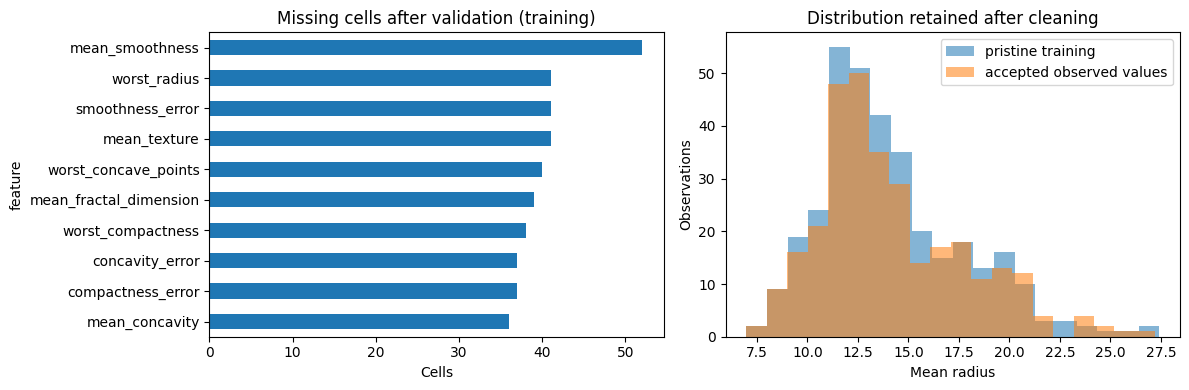

In [14]:
for name, frame in clean_parts.items():
    pristine = real.loc[frame.index]
    valid = frame.notna().to_numpy()
    np.testing.assert_allclose(frame.to_numpy()[valid], pristine.to_numpy()[valid], rtol=1e-8, atol=1e-8)
    repeated = frame.reset_index()
    again, _, quarantine, ledger = audit_and_clean(repeated)
    pd.testing.assert_frame_equal(frame, again)
    assert quarantine.empty and ledger['exact_duplicates'] == 0
    assert set(frame.index).issubset(partitions[name])
    assert 'malignant' not in frame.columns
print('Schema, reconciliation, exact formatting repair, idempotency and target exclusion checks passed.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audits['train'].missing_after.sort_values().tail(10).plot.barh(ax=axes[0], title='Missing cells after validation (training)')
axes[0].set_xlabel('Cells')
axes[1].hist(real.loc[train_ids, 'mean_radius'], bins=20, alpha=0.55, label='pristine training')
axes[1].hist(clean_parts['train'].mean_radius.dropna(), bins=20, alpha=0.55, label='accepted observed values')
axes[1].set(title='Distribution retained after cleaning', xlabel='Mean radius', ylabel='Observations')
axes[1].legend()
plt.tight_layout()
plt.show()

## Training-only preprocessing and a useful comparison

Compare median imputation with missingness indicators against K-nearest-neighbour imputation. KNN uses standardised distances because raw area and radius have very different scales. Each pipeline learns its own scaling and imputation solely on training measurements.

Choose the candidate with the lowest validation Brier score (probability error). The test partition is not used for choosing the model or threshold. The 0.5 classification threshold is fixed in advance; this experiment makes no treatment recommendation.

In [15]:
candidates = {
    'Median + indicators': Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                                    ('scale', StandardScaler()),
                                    ('model', LogisticRegression(C=1.0, max_iter=3000, random_state=SEED))]),
    'Scaled KNN imputation': Pipeline([('scale', StandardScaler()),
                                      ('impute', KNNImputer(n_neighbors=5, add_indicator=True)),
                                      ('model', LogisticRegression(C=1.0, max_iter=3000, random_state=SEED))])
}
X_train, X_validation, X_test = [clean_parts[k] for k in ['train', 'validation', 'test']]
y_train, y_validation, y_test = [labels.loc[f.index].to_numpy() for f in [X_train, X_validation, X_test]]
validation_rows = []
for name, pipeline in candidates.items():
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_validation)[:, 1]
    validation_rows.append({'model': name, 'ROC_AUC': roc_auc_score(y_validation, probabilities),
                            'PR_AUC': average_precision_score(y_validation, probabilities),
                            'Brier': brier_score_loss(y_validation, probabilities)})
validation_results = pd.DataFrame(validation_rows).sort_values('Brier')
selected_name = validation_results.iloc[0]['model']
selected = candidates[selected_name]
display(validation_results.round(4))
print('Selected using validation only:', selected_name)

,model,ROC_AUC,PR_AUC,Brier
0,Median + indicators,0.9997,0.9995,0.0127
1,Scaled KNN imputation,0.9973,0.9964,0.0178


Selected using validation only: Median + indicators


## Final held-out evaluation and uncertainty

Compute metrics once for the validation-selected pipeline. A stratified bootstrap estimates sampling uncertainty conditional on this fitted model; it does not include uncertainty from model retraining or a new clinical population. The simple prevalence baseline is the training malignant rate.

,metric,value,bootstrap_low,bootstrap_high
0,ROC_AUC,0.9970,0.9908,1.0000
1,PR_AUC,0.9952,0.9854,1.0000
2,Brier,0.0281,0.0116,0.0494


Prevalence baseline Brier: 0.2335


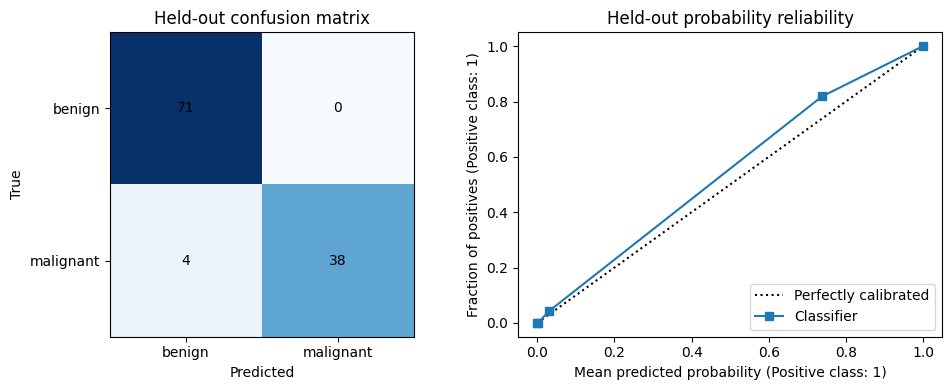

In [16]:
test_probabilities = selected.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = {'ROC_AUC': roc_auc_score(y_test, test_probabilities),
                'PR_AUC': average_precision_score(y_test, test_probabilities),
                'Brier': brier_score_loss(y_test, test_probabilities),
                'Prevalence_baseline_Brier': brier_score_loss(y_test, np.repeat(y_train.mean(), len(y_test)))}
rng = np.random.default_rng(SEED)
bootstrap = []
for _ in range(500):
    idx = np.concatenate([rng.choice(np.flatnonzero(y_test == label), size=int((y_test == label).sum()), replace=True) for label in [0, 1]])
    bootstrap.append([roc_auc_score(y_test[idx], test_probabilities[idx]), average_precision_score(y_test[idx], test_probabilities[idx]), brier_score_loss(y_test[idx], test_probabilities[idx])])
intervals = np.quantile(bootstrap, [0.025, 0.975], axis=0)
display(pd.DataFrame({'metric': ['ROC_AUC', 'PR_AUC', 'Brier'],
                      'value': [test_metrics[k] for k in ['ROC_AUC', 'PR_AUC', 'Brier']],
                      'bootstrap_low': intervals[0], 'bootstrap_high': intervals[1]}).round(4))
print('Prevalence baseline Brier:', round(test_metrics['Prevalence_baseline_Brier'], 4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
matrix = confusion_matrix(y_test, test_predictions)
axes[0].imshow(matrix, cmap='Blues')
for (i, j), value in np.ndenumerate(matrix): axes[0].text(j, i, str(value), ha='center', va='center')
axes[0].set(xticks=[0,1], yticks=[0,1], xticklabels=['benign','malignant'], yticklabels=['benign','malignant'], xlabel='Predicted', ylabel='True', title='Held-out confusion matrix')
CalibrationDisplay.from_predictions(y_test, test_probabilities, n_bins=5, strategy='quantile', ax=axes[1])
axes[1].set_title('Held-out probability reliability')
plt.tight_layout()
plt.show()

## Stress test: increasing missingness

Freeze the chosen model and vary missingness on the same test IDs, using identical random ordering and three seeds. No parse errors or invalid numbers are added in this experiment, so the stress variable is missingness alone. The pristine test data is used only to generate this controlled stress test. No model or parameter changes follow these results. Higher missingness need not cause a monotonic change on a small sample.

,missing_rate,AUC_mean,AUC_std,Brier_mean
0,0.0,0.9980,0.0000,0.0189
1,0.1,0.9950,0.0050,0.0280
2,0.2,0.9874,0.0034,0.0471
3,0.4,0.9548,0.0083,0.1111


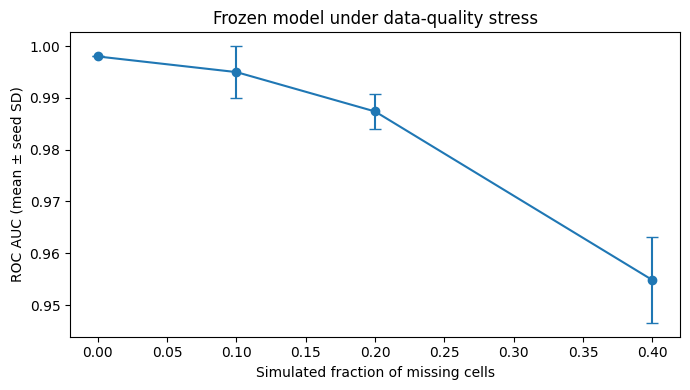

In [17]:
stress_rows = []
for rate in [0.0, 0.1, 0.2, 0.4]:
    for seed in [101, 102, 103]:
        damaged = corrupt_measurements(real.loc[X_test.index], seed, missing_rate=rate, error_rate=0.0, add_conflicts=False)
        stress, _, _, _ = audit_and_clean(damaged)
        assert list(stress.index) == list(X_test.index)
        probabilities = selected.predict_proba(stress)[:, 1]
        stress_rows.append({'missing_rate': rate, 'seed': seed, 'ROC_AUC': roc_auc_score(y_test, probabilities),
                            'Brier': brier_score_loss(y_test, probabilities)})
stress_results = pd.DataFrame(stress_rows)
stress_summary = stress_results.groupby('missing_rate').agg(AUC_mean=('ROC_AUC','mean'), AUC_std=('ROC_AUC','std'), Brier_mean=('Brier','mean')).reset_index()
display(stress_summary.round(4))
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(stress_summary.missing_rate, stress_summary.AUC_mean, yerr=stress_summary.AUC_std, marker='o', capsize=4)
ax.set(xlabel='Simulated fraction of missing cells', ylabel='ROC AUC (mean ± seed SD)', title='Frozen model under data-quality stress')
plt.tight_layout()
plt.show()

## Failure analysis and reproducibility checks

Inspect the most confidently incorrect predictions and whether they have more missing measurements. These are exploratory associations, not a causal explanation. The sample contains no demographic fields, so this analysis cannot make subgroup fairness claims.

In [18]:
failures = pd.DataFrame({'true_label': y_test, 'predicted_label': test_predictions,
                         'malignant_probability': test_probabilities, 'missing_features': X_test.isna().sum(axis=1)}, index=X_test.index)
failures['wrong'] = failures.true_label != failures.predicted_label
failures['error_confidence'] = np.where(failures.predicted_label == 1, failures.malignant_probability, 1-failures.malignant_probability)
display(failures[failures.wrong].sort_values('error_confidence', ascending=False).head(8))
display(failures.groupby('wrong').agg(rows=('wrong','size'), mean_missing_features=('missing_features','mean')))
assert np.isfinite(test_probabilities).all()
median_pipeline = candidates['Median + indicators']
np.testing.assert_allclose(median_pipeline.named_steps['impute'].statistics_, X_train.median().to_numpy())
refit = clone(selected).fit(X_train, y_train)
np.testing.assert_allclose(refit.predict_proba(X_test)[:,1], test_probabilities, atol=1e-10)
try:
    audit_and_clean(dirty['train'].assign(malignant=0))
except ValueError:
    pass
else:
    raise AssertionError('Target-containing input should fail schema validation')
print('Training-only medians, repeatability, finite predictions and target exclusion verified.')
print(f'Finding: {selected_name} selected on validation. Test AUC={test_metrics["ROC_AUC"]:.3f}, PR AUC={test_metrics["PR_AUC"]:.3f}, Brier={test_metrics["Brier"]:.3f}.')

,true_label,predicted_label,malignant_probability,missing_features,wrong,error_confidence
observation_id,,,,,,
WDBC_0073,1,0,0.129149,4,True,0.870851
WDBC_0205,1,0,0.147708,3,True,0.852292
WDBC_0190,1,0,0.482696,4,True,0.517304
WDBC_0099,1,0,0.493330,3,True,0.506670


,rows,mean_missing_features
wrong,,
False,109,2.954128
True,4,3.500000


Training-only medians, repeatability, finite predictions and target exclusion verified.
Finding: Median + indicators selected on validation. Test AUC=0.997, PR AUC=0.995, Brier=0.028.


## What this project establishes

- The cleaning contract can expose numeric errors, quarantine conflicts and reconcile every input row.
- Controlled formatting errors can be repaired exactly; genuinely missing measurements are estimated by training-fitted imputers.
- Validation determines which imputation method to use; held-out performance and stress results are displayed above, whether or not the more complex method wins.
- The starter wearable observations are synthetic; the second experiment uses real historical measurements with simulated corruptions. These are separate evidence sources.

**Limitations:** one small historical dataset, observation-level validation, artificially injected missingness, no external site, no demographic evaluation and no clinical workflow evaluation. Bootstrap intervals cover sampling of this holdout conditional on the fitted model. A real deployment would require source-specific units, patient grouping, external validation and monitoring.

**Interview discussion:** explain why target exclusion, row reconciliation and training-only imputation matter before discussing a model score. All code and measured outputs live in this notebook.